In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("us-arms-export-2010-2025.csv")

1️⃣ מי הן המדינות שהן הלקוחות המרכזיים של תעשיית הנשק האמריקאית?

2️⃣ כיצד השתנה יצוא הנשק האמריקאי לאורך זמן (2010–2025)? (אפשרות למפת העולם

3️⃣ אילו קטגוריות נשק הן הרווחיות / הנפוצות ביותר?

4️⃣אילו עסקאות הן בעלות הערך הגבוה ביותר?

5️⃣מהו זמן האספקה הממוצע של יצוא נשק אמריקאי, וכיצד הוא משתנה בין מדינות וסוגי נשק?




In [ ]:
df.sample(5)

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production
2817,52507,United States,Saudi Arabia,F-110 (13500),turbofan,Engines,2012,Yes,10,Yes,2018,Yes,New,3.25,3.25,32.5,No
1062,67163,United States,Hungary,MPQ-64 Sentinel,air-search radar,Sensors,2020,No,5,Yes,2024,NaN,New,5.00,5.00,25.0,No
3106,62925,United States,South Korea,Mk-54 LWT,anti-submarine torpedo,Missiles,2020,No,15,Yes,2023,Yes,New,0.50,0.50,7.5,No
3631,64810,United States,UAE,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,Missiles,2021,No,300,Yes,2024,Yes,New,0.05,0.05,15.0,No
1337,58813,United States,Israel,JDAM,guided bomb,Missiles,2015,No,100,Yes,2016,Yes,New,0.02,0.02,2.0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4033 entries, 0 to 4032
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SIPRI AT Database ID           4033 non-null   int64  
 1   Supplier                       4033 non-null   object 
 2   Recipient                      4033 non-null   object 
 3   Designation                    4033 non-null   object 
 4   Description                    4033 non-null   object 
 5   Armament category              4033 non-null   object 
 6   Order date                     4033 non-null   int64  
 7   Order date is estimate         4013 non-null   object 
 8   Numbers delivered              4033 non-null   int64  
 9   Numbers delivered is estimate  3954 non-null   object 
 10  Delivery year                  4033 non-null   int64  
 11  Delivery year is estimate      3813 non-null   object 
 12  Status                         4033 non-null   o

In [ ]:
df.describe()

,SIPRI AT Database ID,Order date,Numbers delivered,Delivery year,SIPRI estimate,TIV deal unit,TIV delivery values,deal_value
count,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000
mean,53608.263576,2012.927101,111.813042,2017.076866,8.908651,8.170355,38.409455,38.409455
std,11006.807638,5.852277,541.638153,4.305202,24.941441,23.023946,99.851514,99.851514
min,4031.000000,1984.000000,1.000000,2010.000000,0.010000,0.000000,0.060000,0.060000
25%,51040.000000,2009.000000,2.000000,2013.000000,0.140000,0.110000,3.100000,3.100000
50%,56805.000000,2014.000000,10.000000,2017.000000,0.900000,0.750000,9.570000,9.570000
75%,61417.000000,2017.000000,50.000000,2021.000000,5.000000,4.600000,29.000000,29.000000
max,68511.000000,2024.000000,12500.000000,2024.000000,300.000000,250.000000,1950.000000,1950.000000


In [ ]:
df.isnull().sum()

,0
SIPRI AT Database ID,0
Supplier,0
Recipient,0
Designation,0
Description,0
Armament category,0
Order date,0
Order date is estimate,20
Numbers delivered,0
Numbers delivered is estimate,79


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.isnull()

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4028,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4029,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4030,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
4031,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df["delivery_time_years"] = df["Delivery year"] - df["Order date"] #כמה שנים עברו מרגע שהנשק הוזמן ועד לרגע שהוא סופק בפועל.
df

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production,delivery_time_years
0,60445,United States,Afghanistan,S-70A Black Hawk,transport helicopter,Aircraft,2016,No,4,No,2017,No,Second hand but modernized,6.50,4.29,17.16,No,1
1,60445,United States,Afghanistan,S-70A Black Hawk,transport helicopter,Aircraft,2016,No,27,Yes,2018,No,Second hand but modernized,6.50,4.29,115.83,No,2
2,60445,United States,Afghanistan,S-70A Black Hawk,transport helicopter,Aircraft,2016,No,19,Yes,2019,No,Second hand but modernized,6.50,4.29,81.51,No,3
3,60445,United States,Afghanistan,S-70A Black Hawk,transport helicopter,Aircraft,2016,No,3,Yes,2020,No,Second hand but modernized,6.50,4.29,12.87,No,4
4,61920,United States,Afghanistan,Paveway,guided bomb,Missiles,2017,Yes,100,Yes,2018,No,New,0.02,0.02,2.00,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4028,56355,United States,Yemen,Cessna-208 Caravan,light transport aircraft,Aircraft,2012,No,2,No,2013,No,New,1.00,1.00,2.00,No,1
4029,66970,United States,Zambia,Bell-412,helicopter,Aircraft,2023,No,1,Yes,2023,Yes,New,5.00,5.00,5.00,No,0
4030,66454,United States,Zambia,Enstrom-480,light helicopter,Aircraft,2023,No,2,NaN,2024,NaN,New,0.40,0.40,0.80,No,1
4031,65459,United States,Zambia,Cessna-208 Caravan,light transport aircraft,Aircraft,2020,No,1,No,2020,No,New,1.00,1.00,1.00,No,0


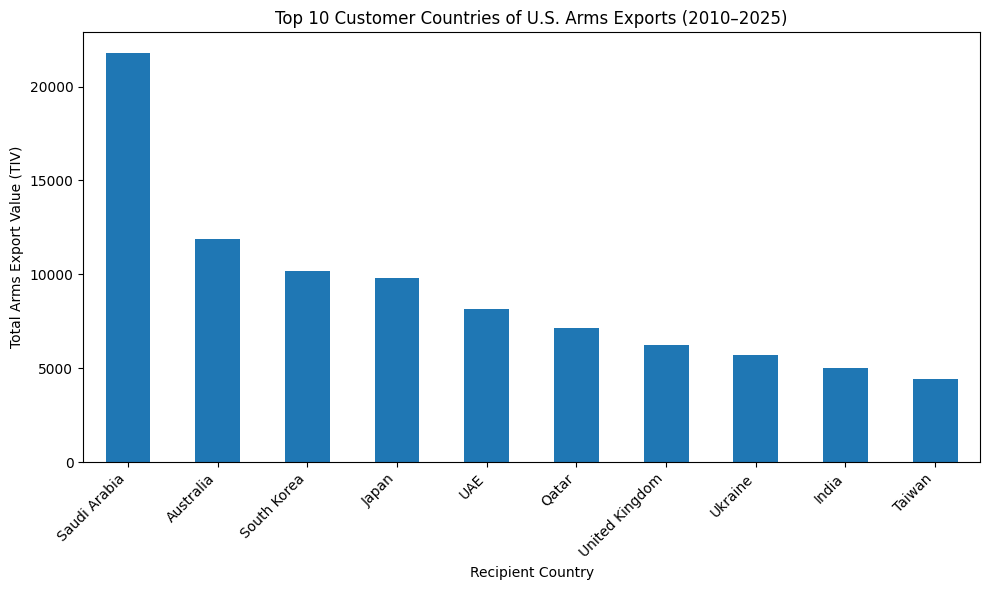

In [ ]:
import matplotlib.pyplot as plt

# יצירת שווי עסקה אחיד
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])

# אגרגציה לפי מדינה
df_top10 = (
    df.dropna(subset=["Recipient", "deal_value"])
      .groupby("Recipient", as_index=False)
      .agg(total_deal_value=("deal_value", "sum"))
      .sort_values(by="total_deal_value", ascending=False)
      .head(10)

)

df_top10.plot(
    kind="bar",
    x="Recipient",
    y="total_deal_value",
    figsize=(10,6),
    legend=False,
    title="Top 10 Customer Countries of U.S. Arms Exports (2010–2025)"
)

plt.xlabel("Recipient Country")
plt.ylabel("Total Arms Export Value (TIV)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
saudi_purchases = (
    df[
        df["Recipient"].astype(str).str.contains("Saudi", case=False, na=False)
    ][
        ["Order date", "Delivery year", "Description", "deal_value"]
    ]
    .sort_values(by="deal_value", ascending=False)
)

saudi_purchases


,Order date,Delivery year,Description,deal_value
2839,2011,2017,FGA aircraft,1950.00
2840,2011,2018,FGA aircraft,1800.00
2841,2011,2019,FGA aircraft,1650.00
2842,2011,2020,FGA aircraft,750.00
2782,2011,2023,FGA aircraft,621.00
...,...,...,...,...
2789,2014,2015,vehicle engine,1.20
2833,2009,2011,guided bomb,1.00
2832,2009,2010,guided bomb,1.00
2790,2014,2016,vehicle engine,0.45


**סעודיה רכשה בעיקר מטוסי קרב (FGA aircraft), שהם גם הנפוצים ביותר בדאטה וגם בעלי השווי הכספי הגבוה ביותר.**

In [ ]:
df["Recipient"].value_counts().head(20)


,count
Recipient,
Japan,257
Saudi Arabia,238
South Korea,176
Australia,174
UAE,148
Ukraine,132
Turkiye,114
Taiwan,111
Iraq,108


In [ ]:
Australia_purchases = (
    df[
        df["Recipient"].astype(str).str.contains("Australia", case=False, na=False)
    ][
        ["Order date", "Delivery year", "Description", "deal_value"]
    ]
    .sort_values(by="deal_value", ascending=False)
)

Australia_purchases

,Order date,Delivery year,Description,deal_value
243,2009,2021,FGA aircraft,825.00
242,2009,2020,FGA aircraft,825.00
195,2007,2010,FGA aircraft,750.00
244,2009,2022,FGA aircraft,660.00
180,2000,2010,airborne early-warning aircraft,500.00
...,...,...,...,...
203,2022,2024,UAV,1.68
162,2008,2010,vehicle engine,1.23
288,2012,2012,vehicle engine,0.75
139,2010,2011,UAV,0.50


In [ ]:
israel_purchases = (
    df[
        df["Recipient"].astype(str).str.contains("Israel", case=False, na=False)
    ][
        ["Order date", "Delivery year", "Description", "deal_value"]
    ]
    .sort_values(by="deal_value", ascending=False)
)

israel_purchases

,Order date,Delivery year,Description,deal_value
1358,2010,2017,FGA aircraft,385.00
1330,2015,2021,FGA aircraft,330.00
1359,2010,2018,FGA aircraft,275.00
1360,2010,2019,FGA aircraft,275.00
1329,2015,2020,FGA aircraft,220.00
...,...,...,...,...
1362,2008,2010,guided glide bomb,1.00
1324,2014,2016,long-range air-to-air missile,0.90
1325,2014,2017,long-range air-to-air missile,0.90
1378,2023,2023,armoured personnel carrier,0.72


In [ ]:
israel_2023_deliveries = (
    df[
        df["Recipient"].astype(str).str.contains("Israel", case=False, na=False)
        & (df["Delivery year"] >= 2023)
    ][
        ["Order date", "Delivery year", "Description", "deal_value"]
    ]
    .sort_values(by="deal_value", ascending=False)
)

israel_2023_deliveries


,Order date,Delivery year,Description,deal_value
1374,2017,2023,FGA aircraft,165.00
1390,2011,2024,armoured personnel carrier,75.00
1389,2011,2023,armoured personnel carrier,75.00
1393,2019,2024,landing ship,40.00
1392,2019,2023,landing ship,40.00
1375,2023,2023,anti-tank/air-to-surface missile,40.00
1332,2021,2023,guided bomb,36.00
1354,2017,2023,light transport aircraft,28.00
1310,2023,2024,guided glide bomb,20.80
1379,2023,2023,SAM system,20.00


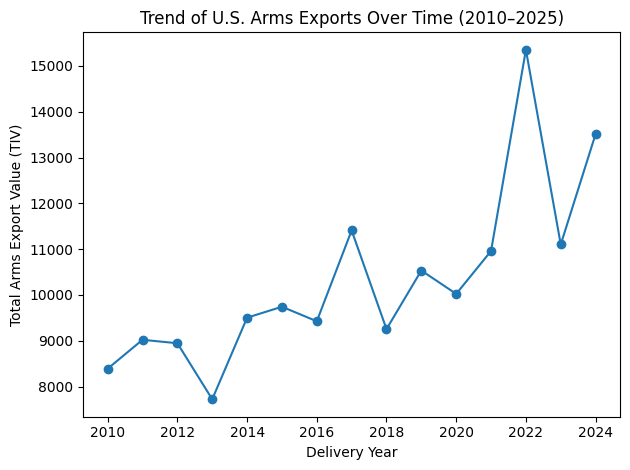

In [ ]:
import matplotlib.pyplot as plt

# יצירת מדד כספי אחיד
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])

# אגרגציה לפי שנת אספקה
df_trend = (
    df.dropna(subset=["Delivery year", "deal_value"])
      .groupby("Delivery year", as_index=False)
      .agg(total_deal_value=("deal_value", "sum"))
      .sort_values("Delivery year")
)

# גרף מגמה לאורך זמן
plt.figure()
plt.plot(df_trend["Delivery year"], df_trend["total_deal_value"], marker='o')
plt.xlabel("Delivery Year")
plt.ylabel("Total Arms Export Value (TIV)")
plt.title("Trend of U.S. Arms Exports Over Time (2010–2025)")
plt.tight_layout()
plt.show()


**שאלה 3: **

In [ ]:
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])


In [ ]:
df_category = df.dropna(subset=["Armament category", "deal_value"])


In [ ]:
df_category_summary = (
    df_category
    .groupby("Armament category", as_index=False)
    .agg(
        total_deal_value=("deal_value", "sum"),
        number_of_deals=("Armament category", "count")
    )
    .sort_values(by="total_deal_value", ascending=False)
)


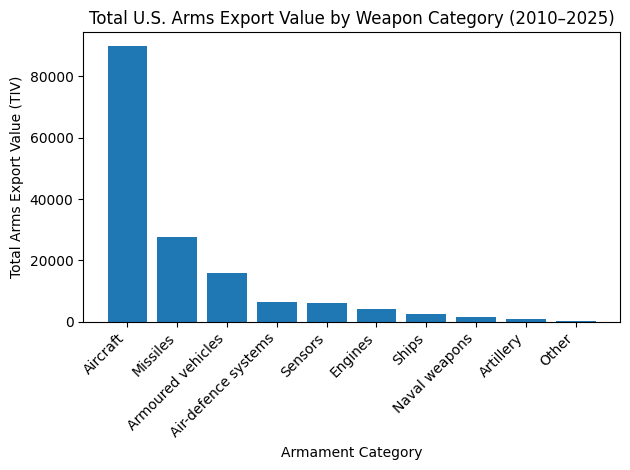

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    df_category_summary["Armament category"],
    df_category_summary["total_deal_value"]
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Armament Category")
plt.ylabel("Total Arms Export Value (TIV)")
plt.title("Total U.S. Arms Export Value by Weapon Category (2010–2025)")
plt.tight_layout()
plt.show()


שאלה 4

In [ ]:
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])


In [ ]:
df_deals = df.dropna(subset=["deal_value", "Recipient", "Designation"])


In [ ]:
df_top_deals = (
    df_deals
    .sort_values(by="deal_value", ascending=False)
    .head(10)
)


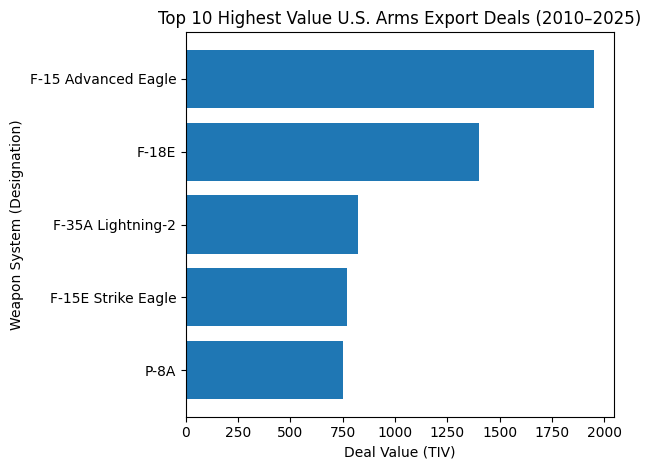

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(df_top_deals["Designation"], df_top_deals["deal_value"])
plt.xlabel("Deal Value (TIV)")
plt.ylabel("Weapon System (Designation)")
plt.title("Top 10 Highest Value U.S. Arms Export Deals (2010–2025)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


שאלה 5

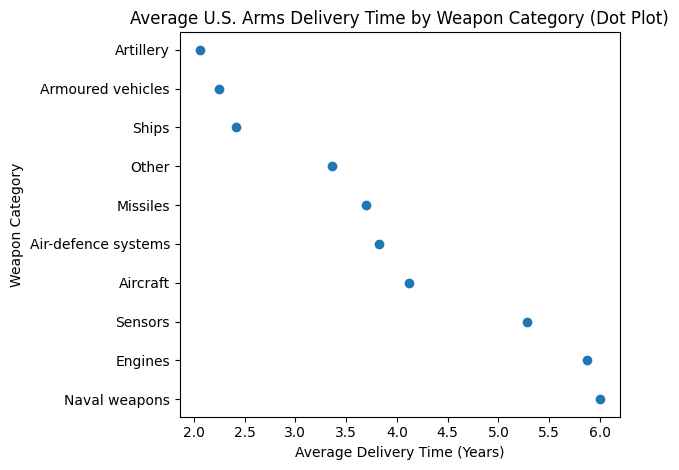

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# חישוב זמן אספקה
df["delivery_time_years"] = df["Delivery year"] - df["Order date"]

# סינון לוגי (רק ערכים תקינים)
df_delivery = df[
    (df["delivery_time_years"].notna()) &
    (df["delivery_time_years"] >= 0)
]

# חישוב זמן אספקה ממוצע לפי קטגוריית נשק
df_category_time = (
    df_delivery
    .groupby("Armament category", as_index=False)
    .agg(avg_delivery_time=("delivery_time_years", "mean"))
    .sort_values(by="avg_delivery_time", ascending=False)
)

# ציור Dot Plot
plt.figure()
plt.scatter(
    df_category_time["avg_delivery_time"],
    df_category_time["Armament category"]
)
plt.xlabel("Average Delivery Time (Years)")
plt.ylabel("Weapon Category")
plt.title("Average U.S. Arms Delivery Time by Weapon Category (Dot Plot)")
plt.tight_layout()
plt.show()


*********************************************************

תוספת לשאלה 1

In [ ]:
import pandas as pd
import plotly.express as px

# יצירת שווי עסקה אחיד
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])

# אגרגציה לפי מדינה ושנה
df_map = (
    df.dropna(subset=["Recipient", "Delivery year", "deal_value"])
      .groupby(["Recipient", "Delivery year"], as_index=False)
      .agg(total_deal_value=("deal_value", "sum"))
)


In [ ]:
fig = px.choropleth(
    df_map,
    locations="Recipient",
    locationmode="country names",
    color="total_deal_value",
    hover_name="Recipient",
    animation_frame="Delivery year",
    color_continuous_scale="Blues",
    labels={"total_deal_value": "Total Arms Import Value (TIV)"},
    title="U.S. Arms Exports by Country Over Time (2010–2025)"
)

fig.show()


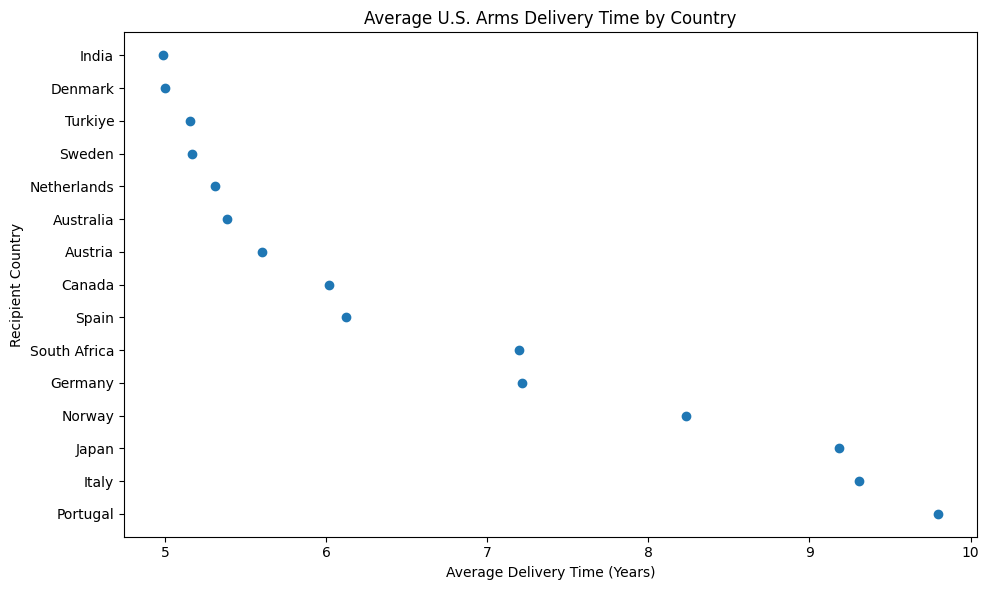

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# חישוב זמן אספקה
df["delivery_time_years"] = df["Delivery year"] - df["Order date"]

# סינון ערכים תקינים בלבד
df_delivery = df[
    (df["delivery_time_years"].notna()) &
    (df["delivery_time_years"] >= 0)
]

# חישוב זמן אספקה ממוצע לפי מדינה
df_country_time = (
    df_delivery
    .groupby("Recipient", as_index=False)
    .agg(avg_delivery_time=("delivery_time_years", "mean"),
         deals=("delivery_time_years", "count"))
)

# ניקח רק מדינות עם מספיק עסקאות (כדי למנוע הטיות)
df_country_time = df_country_time[df_country_time["deals"] >= 5]

# ניקח Top 15 מדינות עם זמן האספקה הגבוה ביותר
df_country_time = df_country_time.sort_values("avg_delivery_time", ascending=False).head(15)

# גרף Dot Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df_country_time["avg_delivery_time"],
    df_country_time["Recipient"]
)

plt.xlabel("Average Delivery Time (Years)")
plt.ylabel("Recipient Country")
plt.title("Average U.S. Arms Delivery Time by Country")
plt.tight_layout()

plt.show()


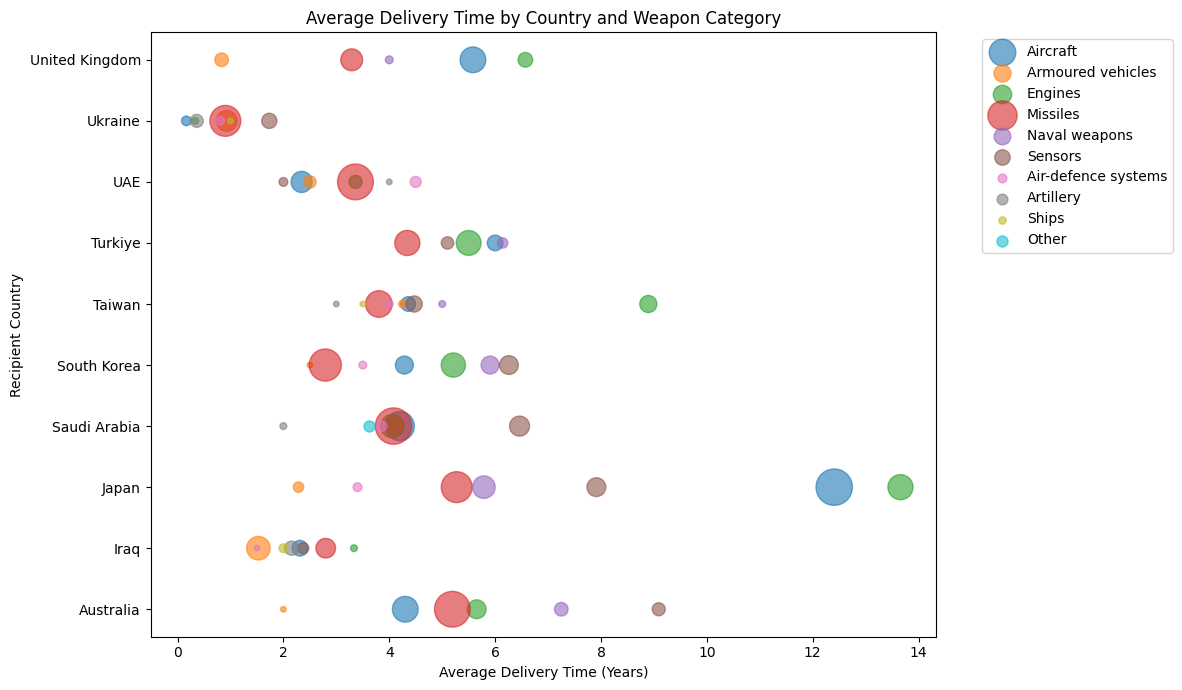

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# חישוב זמן אספקה
df["delivery_time_years"] = df["Delivery year"] - df["Order date"]

# סינון נתונים תקינים
df_delivery = df[
    (df["delivery_time_years"].notna()) &
    (df["delivery_time_years"] >= 0)
]

# חישוב ממוצעים לפי מדינה + סוג נשק
df_country_cat = (
    df_delivery
    .groupby(["Recipient", "Armament category"], as_index=False)
    .agg(
        avg_delivery_time=("delivery_time_years", "mean"),
        deals=("delivery_time_years", "count")
    )
)

# ניקח רק מדינות עם הרבה עסקאות
top_countries = (
    df_delivery["Recipient"]
    .value_counts()
    .head(10)
    .index
)

df_country_cat = df_country_cat[df_country_cat["Recipient"].isin(top_countries)]

# ציור Bubble Chart
plt.figure(figsize=(12,7))

for category in df_country_cat["Armament category"].unique():
    subset = df_country_cat[df_country_cat["Armament category"] == category]

    plt.scatter(
        subset["avg_delivery_time"],
        subset["Recipient"],
        s=subset["deals"] * 8,   # גודל הבועה = מספר עסקאות
        alpha=0.6,
        label=category
    )

plt.xlabel("Average Delivery Time (Years)")
plt.ylabel("Recipient Country")
plt.title("Average Delivery Time by Country and Weapon Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
fig = px.choropleth(
    df_map,
    locations="country_name",
    locationmode="country names",
    color="total_value",
    animation_frame="Delivery year",
    range_color=(0, df_map["total_value"].max()),
    hover_name="country_name",
    color_continuous_scale="Viridis",
    labels={"total_value": "Total Arms Export Value (TIV)"},
    category_orders={"Delivery year": year_order},
    title="U.S. Arms Exports by Country Over Time (2010–2025)"
)

fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# 1️⃣ טעינת הדאטה
df = pd.read_csv("us-arms-export-2010-2025.csv")

# 2️⃣ יצירת ערך כספי אחיד (TIV בפועל, ואם חסר – הערכת SIPRI)
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])

# 3️⃣ בניית דאטה למפה: סך ערך לפי מדינה ושנת אספקה
df_map = (
    df.dropna(subset=["Recipient", "Delivery year", "deal_value"])
      .groupby(["Recipient", "Delivery year"], as_index=False)
      .agg(total_value=("deal_value", "sum"))
      .rename(columns={"Recipient": "country_name"})
)

# 4️⃣ תיקון טיפוס וסדר כרונולוגי
df_map["Delivery year"] = df_map["Delivery year"].astype(int)
df_map = df_map.sort_values("Delivery year")
year_order = sorted(df_map["Delivery year"].unique())

# 5️⃣ גרף Choropleth (סקאלה ליניארית, TIV)
fig = px.choropleth(
    df_map,
    locations="country_name",
    locationmode="country names",
    color="total_value",
    animation_frame="Delivery year",
    range_color=(0, df_map["total_value"].max()),
    hover_name="country_name",
    hover_data={"total_value": ":,.0f"},
    color_continuous_scale="Viridis",
    labels={"total_value": "Total Arms Export Value (TIV)"},
    category_orders={"Delivery year": year_order},
    title="U.S. Arms Exports by Country Over Time (2010–2025)"
)

fig.update_layout(template="plotly_white")
fig.show()


In [ ]:
df_trend = (
    df.dropna(subset=["Delivery year", "deal_value"])
      .groupby("Delivery year", as_index=False)
      .agg(total_deal_value=("deal_value", "sum"))
      .sort_values("Delivery year")
)

fig = px.line(
    df_trend,
    x="Delivery year", y="total_deal_value",
    markers=True,
    labels={"total_deal_value":"Total TIV"},
    title="Trend of U.S. Arms Exports Over Time (2010–2025)"
)
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# אם df כבר טעון אצלך – דלג על השורה הזו
# df = pd.read_csv("us-arms-export-2010-2025.csv")

# ערך כספי אחיד
df["deal_value"] = df["TIV delivery values"].fillna(df["SIPRI estimate"])

# Top 10 מדינות לפי שווי מצטבר
df_top10 = (
    df.dropna(subset=["Recipient", "deal_value"])
      .groupby("Recipient", as_index=False)
      .agg(total_deal_value=("deal_value", "sum"))
      .sort_values("total_deal_value", ascending=False)
      .head(10)
)

# גרף Plotly משופר
fig = px.bar(
    df_top10,
    x="Recipient",
    y="total_deal_value",
    text="total_deal_value",
    title="Top 10 Customer Countries of U.S. Arms Exports (2010–2025)",
    labels={
        "Recipient": "Recipient Country",
        "total_deal_value": "Total Arms Export Value (TIV)"
    }
)

# שדרוג עיצוב/קריאות
fig.update_traces(texttemplate="%{text:.0f}", textposition="outside")
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    yaxis_title="Total Arms Export Value (TIV)",
    xaxis_title="Recipient Country",
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)

fig.show()
